# Checkpoint 02 — APIs, energias renováveis e aprendizado de máquina

- Gabriel Fagundes - RM: 569074
- Gabriel Freitas - RM: 572943
- Giovanni Merlotti - RM: 573721
- Glauco Kelly - RM: 572840
- Sergio Augusto Amaral - RM: 570184
- Thiago Renatino - RM: 569073


1CCR · 2º semestre

Neste notebook eu:

1. consulto duas APIs públicas (ANEEL/SIGA e Open-Meteo) e gero os CSVs `aneel_classificacao_orange.csv` e `meteo_regressao_orange.csv`;
2. resolvo a **Tarefa 1 (classificação)**: prever se um empreendimento é *Solar*, *Eólica* ou *Hidráulica* usando só potência e localização, comparando **KNN, Regressão Logística e Random Forest**;
3. resolvo a **Tarefa 2 (regressão)**: estimar a radiação solar horária em Petrolina (PE), comparando **Regressão Linear, Árvore de Decisão e Random Forest**.

As duas APIs são públicas e **não usam token**. Se alguma consulta falhar (rede fora, API mudou etc.), o notebook carrega a cópia dos CSVs publicada no repositório da disciplina, para continuar rodando do começo ao fim.

## 0. Imports

In [1]:
# Bibliotecas padrão (usadas na consulta às APIs)
import json
import urllib.parse
import urllib.request
import csv

# Análise e gráficos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             mean_absolute_error, mean_squared_error, r2_score)

SEMENTE = 42  # semente fixa para tudo ser reproduzível
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Função de consulta às APIs (fornecida no notebook de apoio)

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Cópias dos CSVs no repositório da disciplina (plano B se a API falhar)
BACKUP = "https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/"

# Tarefa 1 — Classificação da fonte renovável (ANEEL)

**Pergunta:** só com potência outorgada e localização dá para saber se o empreendimento é Solar, Eólica ou Hidráulica?

O alvo é uma **categoria**, então é um problema de **classificação**. `UHE`, `PCH` e `CGH` viram uma classe só (*Hidráulica*). Importante: a potência outorgada é a potência **autorizada**, não a energia gerada.

## 1.1 Consulta à API e geração do CSV

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]

def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}

try:
    registros_aneel = []
    for sigla in SIGLAS:
        parametros = {"resource_id": ID_RECURSO,
                      "filters": json.dumps({"SigTipoGeracao": sigla}),
                      "limit": 1200}
        resposta = consultar_api(URL_ANEEL, parametros)
        if not resposta.get("success"):
            raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
        linhas = resposta["result"]["records"]
        print(f"{sigla}: {len(linhas)} linhas recebidas")
        registros_aneel.extend(linhas)

    linhas_classificacao = []
    for registro in registros_aneel:
        potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
        latitude = numero(registro.get("NumCoordNEmpreendimento"))
        longitude = numero(registro.get("NumCoordEEmpreendimento"))
        fonte = fontes.get(registro.get("SigTipoGeracao"))
        if fonte and all(v is not None for v in (potencia, latitude, longitude)):
            linhas_classificacao.append([potencia, latitude, longitude, fonte])
    if len(linhas_classificacao) < 90:
        raise ValueError("Poucos registros válidos")

    with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arq:
        escritor = csv.writer(arq)
        escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
        escritor.writerows(linhas_classificacao)
    print("CSV gerado pela API:", len(linhas_classificacao), "linhas")
    dados = pd.read_csv("aneel_classificacao_orange.csv", encoding="utf-8-sig")
except Exception as erro:
    print("API da ANEEL indisponível -> usando a cópia do repositório.", erro)
    dados = pd.read_csv(BACKUP + "aneel_classificacao_orange.csv", encoding="utf-8-sig")
    dados.to_csv("aneel_classificacao_orange.csv", index=False, encoding="utf-8-sig")

dados.head()

API da ANEEL indisponível -> usando a cópia do repositório. Não foi possível consultar a API: HTTP Error 403: Forbidden


,potencia_kw,latitude,longitude,fonte
0,20.480,-10.443,-64.152,Solar
1,"5,000.000",-6.004,-40.275,Solar
2,12.260,-23.558,-46.734,Solar
3,3.000,-23.559,-46.735,Solar
4,1.700,-23.494,-46.845,Solar


## 1.2 Análise exploratória

In [4]:
print("Linhas x colunas:", dados.shape)
print()
dados.info()
print()
print("Valores ausentes por coluna:")
print(dados.isna().sum())
print()
print("Linhas duplicadas:", dados.duplicated().sum())

Linhas x colunas: (3876, 4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB

Valores ausentes por coluna:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Linhas duplicadas: 28


fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64

fonte
Hidráulica    38.1 %
Solar         31.0 %
Eólica        31.0 %
Name: count, dtype: object


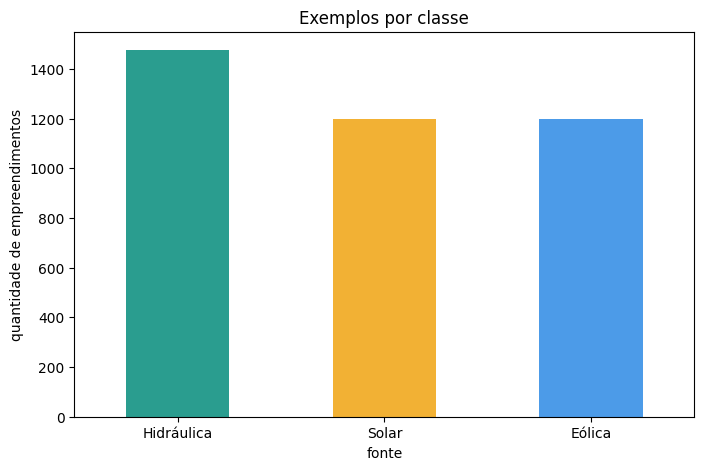

In [5]:
contagem = dados["fonte"].value_counts()
print(contagem)
print()
print((contagem / len(dados) * 100).round(1).astype(str) + " %")
cores = {"Solar": "#f2b134", "Eólica": "#4c9be8", "Hidráulica": "#2a9d8f"}
contagem.plot(kind="bar", color=[cores[f] for f in contagem.index], title="Exemplos por classe")
plt.ylabel("quantidade de empreendimentos"); plt.xticks(rotation=0); plt.show()

In [6]:
dados.groupby("fonte")[["potencia_kw", "latitude", "longitude"]].describe().T

fonte                  Eólica     Hidráulica       Solar
potencia_kw count   1,200.000      1,476.000   1,200.000
            mean   30,782.770     75,809.158  11,679.387
            std    13,800.598    486,419.579  18,374.855
            min         0.160          0.990       0.260
            25%    23,100.000        990.000       1.000
            50%    29,600.000      4,000.000       1.000
            75%    37,200.000     17,000.000  28,880.000
            max   105,000.000 11,233,100.000 137,480.000
latitude    count   1,200.000      1,476.000   1,200.000
            mean       -9.896        -21.113      -5.136
            std         7.530          6.500       5.547
            min       -33.723        -30.788     -29.836
            25%       -11.136        -26.754      -6.925
            50%        -7.986        -22.031      -2.056
            75%        -5.271        -17.605      -1.831
            max         0.000          3.802       3.831
longitude   count   1,200.000      1,476.000   1,200.000
            mean      -39.716        -48.932     -49.188
            std         7.232          7.977       5.912
            min       -55.931        -64.646     -69.941
            25%       -41.865        -52.632     -53.068
            50%       -40.692        -50.419     -52.441
            75%       -36.492        -46.199     -44.881
            max         0.000          0.000     -35.235

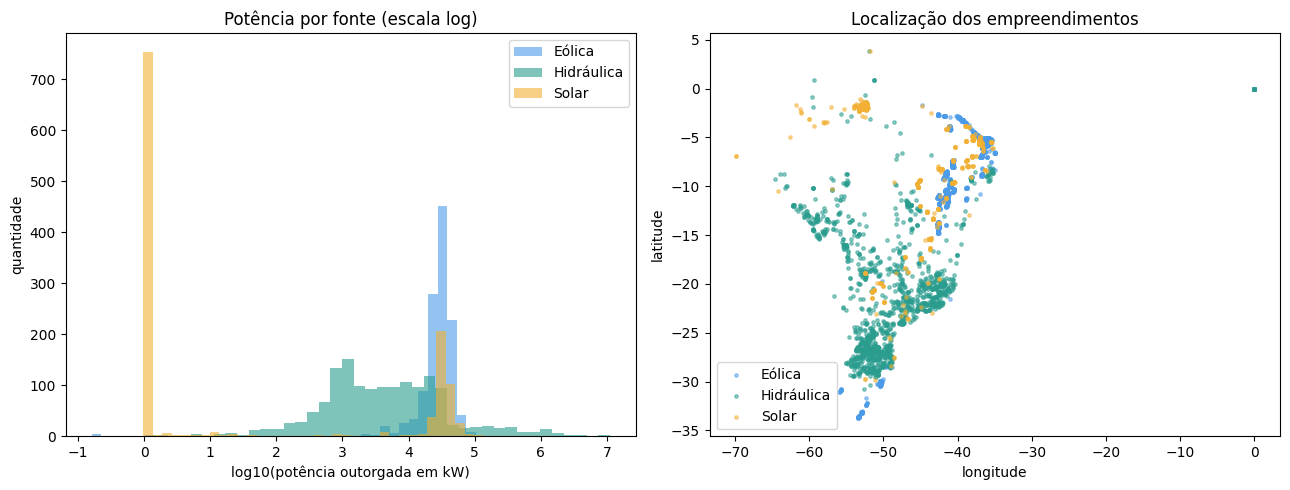

In [7]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 5))

for fonte, grupo in dados.groupby("fonte"):
    eixos[0].hist(np.log10(grupo["potencia_kw"]), bins=40, alpha=0.6, label=fonte, color=cores[fonte])
eixos[0].set_xlabel("log10(potência outorgada em kW)")
eixos[0].set_ylabel("quantidade")
eixos[0].set_title("Potência por fonte (escala log)")
eixos[0].legend()

for fonte, grupo in dados.groupby("fonte"):
    eixos[1].scatter(grupo["longitude"], grupo["latitude"], s=6, alpha=0.5, label=fonte, color=cores[fonte])
eixos[1].set_xlabel("longitude"); eixos[1].set_ylabel("latitude")
eixos[1].set_title("Localização dos empreendimentos")
eixos[1].legend()
plt.tight_layout(); plt.show()

**O que eu observei na exploração:**

- Não há valores ausentes (o próprio notebook de apoio já descartou linhas sem potência ou coordenadas).
- As classes estão **razoavelmente equilibradas**, mas não totalmente: *Hidráulica* tem mais exemplos porque junta três siglas (UHE, PCH, CGH). Esse número vem do `limit=1200` por sigla da consulta, então **não representa** a participação de cada fonte na matriz energética brasileira.
- A potência é **muito assimétrica**: vai de menos de 1 kW (microgeração solar) até mais de 11 milhões de kW (grandes hidrelétricas). Por isso olhei em escala log.
- Existem empreendimentos com coordenada **(0, 0)**, que é um ponto no Oceano Atlântico, ou seja, é erro de cadastro. Vou removê-los na limpeza abaixo.
- No mapa dá pra ver padrões: eólicas concentradas no litoral do Nordeste e no Sul; hidráulicas espalhadas pelo Sul/Sudeste/Centro-Oeste; solares aparecem em quase todo o país.

## 1.3 Limpeza e definição de X e y

In [8]:
coord_invalida = (dados["latitude"] == 0) & (dados["longitude"] == 0)
print("Linhas com coordenada (0, 0):", coord_invalida.sum())
print(dados.loc[coord_invalida, "fonte"].value_counts())

dados_limpos = dados.loc[~coord_invalida].reset_index(drop=True)
print("Linhas após a limpeza:", len(dados_limpos))

# X: SÓ as 3 entradas permitidas (nada de nome, CEG ou sigla, que entregariam a resposta)
X = dados_limpos[["potencia_kw", "latitude", "longitude"]].copy()
# A potência tem escala enorme; uso log10(1 + kW). É uma conta linha a linha,
# não aprende nada dos dados, então não há vazamento do teste.
X["potencia_kw"] = np.log10(1 + X["potencia_kw"])
X = X.rename(columns={"potencia_kw": "log10_potencia_kw"})
y = dados_limpos["fonte"]

print(X.shape, y.shape)
X.head()

Linhas com coordenada (0, 0): 47
fonte
Eólica        24
Hidráulica    23
Name: count, dtype: int64
Linhas após a limpeza: 3829
(3829, 3) (3829,)


,log10_potencia_kw,latitude,longitude
0,1.332,-10.443,-64.152
1,3.699,-6.004,-40.275
2,1.123,-23.558,-46.734
3,0.602,-23.559,-46.735
4,0.431,-23.494,-46.845


## 1.4 Divisão treino/teste estratificada

80% treino / 20% teste, `stratify=y` (mantém a proporção das classes nos dois conjuntos) e `random_state=42`.

In [9]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEMENTE)

print("Treino:", X_treino.shape, "| Teste:", X_teste.shape)
pd.DataFrame({"treino (%)": y_treino.value_counts(normalize=True) * 100,
              "teste (%)": y_teste.value_counts(normalize=True) * 100}).round(1)

Treino: (3063, 3) | Teste: (766, 3)


,treino (%),teste (%)
fonte,,
Hidráulica,37.900,38.000
Solar,31.300,31.300
Eólica,30.700,30.700


## 1.5 Os três classificadores

| Modelo | Por que escolhi | Precisa padronizar? |
|---|---|---|
| **KNN (k = 7)** | Classifica olhando os vizinhos mais próximos. Faz sentido aqui porque empreendimentos próximos no mapa e com potência parecida costumam ser do mesmo tipo. | **Sim** — ele usa distância, então coloco o `StandardScaler` dentro de um *pipeline*. |
| **Regressão Logística** | Modelo linear simples, serve de *baseline*. Mostra até onde dá pra ir só com fronteiras retas. | **Sim** — ajuda a convergir e deixa os coeficientes comparáveis. |
| **Random Forest (200 árvores)** | Conjunto de árvores; captura regiões “recortadas” do mapa e faixas de potência sem precisar de escala. | Não. |

Usar `make_pipeline(StandardScaler(), modelo)` garante que a média e o desvio do scaler são calculados **só com o treino** no `.fit()` e depois apenas aplicados no teste.

In [10]:
classificadores = {
    "KNN (k=7)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7)),
    "Regressão Logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=SEMENTE)),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=SEMENTE, n_jobs=-1),
}

resultados_clf = []
previsoes_clf = {}
for nome, modelo in classificadores.items():
    modelo.fit(X_treino, y_treino)
    y_prev = modelo.predict(X_teste)
    previsoes_clf[nome] = y_prev
    resultados_clf.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_teste, y_prev),
        "Precision (macro)": precision_score(y_teste, y_prev, average="macro"),
        "Recall (macro)": recall_score(y_teste, y_prev, average="macro"),
        "F1 (macro)": f1_score(y_teste, y_prev, average="macro"),
    })

tabela_clf = pd.DataFrame(resultados_clf).set_index("Modelo").sort_values("F1 (macro)", ascending=False)
print("Mesma divisão para os 3: 80/20 estratificado, random_state=42, teste com", len(y_teste), "linhas")
tabela_clf

Mesma divisão para os 3: 80/20 estratificado, random_state=42, teste com 766 linhas


,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Modelo,,,,
Random Forest,0.977,0.977,0.976,0.977
KNN (k=7),0.967,0.968,0.966,0.967
Regressão Logística,0.832,0.847,0.828,0.825


**Sobre a média das métricas:** usei **`average="macro"`**: calcula a métrica para cada classe e tira a média simples. Assim, as três classes pesam igual, mesmo a *Hidráulica* tendo mais exemplos. Como as classes estão quase equilibradas, a média `weighted` daria valores bem próximos.

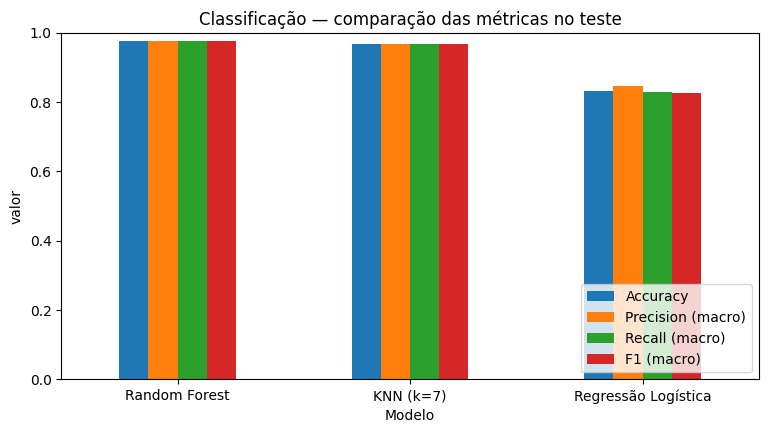

In [11]:
tabela_clf.plot(kind="bar", figsize=(9, 4.5), ylim=(0, 1), rot=0,
                title="Classificação — comparação das métricas no teste")
plt.ylabel("valor"); plt.legend(loc="lower right"); plt.show()

## 1.6 Matrizes de confusão

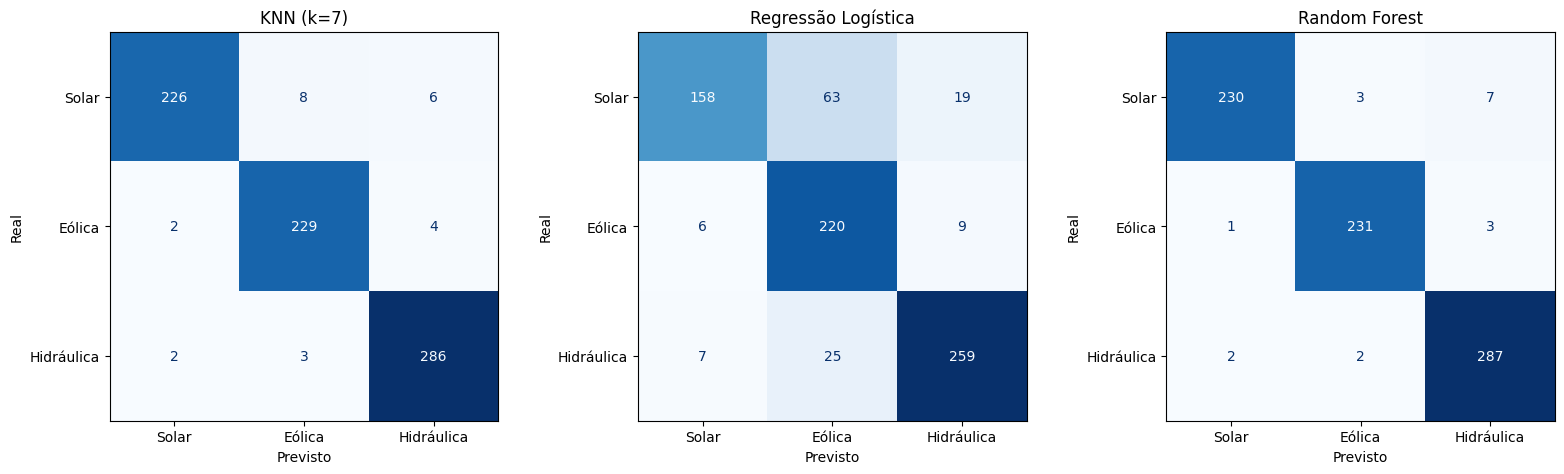

In [12]:
classes = ["Solar", "Eólica", "Hidráulica"]
fig, eixos = plt.subplots(1, 3, figsize=(16, 4.8))
for eixo, (nome, y_prev) in zip(eixos, previsoes_clf.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_teste, y_prev, labels=classes),
                           display_labels=classes).plot(ax=eixo, cmap="Blues", colorbar=False)
    eixo.set_title(nome)
    eixo.set_xlabel("Previsto"); eixo.set_ylabel("Real")
plt.tight_layout(); plt.show()

In [13]:
melhor_clf = tabela_clf.index[0]
print("Relatório por classe do melhor modelo:", melhor_clf)
print(classification_report(y_teste, previsoes_clf[melhor_clf], digits=3))

Relatório por classe do melhor modelo: Random Forest
              precision    recall  f1-score   support

      Eólica      0.979     0.983     0.981       235
  Hidráulica      0.966     0.986     0.976       291
       Solar      0.987     0.958     0.973       240

    accuracy                          0.977       766
   macro avg      0.977     0.976     0.977       766
weighted avg      0.977     0.977     0.976       766



In [14]:
# Quais as confusões mais frequentes de cada modelo (fora da diagonal)?
for nome, y_prev in previsoes_clf.items():
    cm = pd.DataFrame(confusion_matrix(y_teste, y_prev, labels=classes), index=classes, columns=classes)
    erros = cm.where(~np.eye(3, dtype=bool)).stack().sort_values(ascending=False)
    print(f"{nome}: " + ", ".join(f"{r}->{p}: {int(v)}" for (r, p), v in erros.head(3).items()))

KNN (k=7): Solar->Eólica: 8, Solar->Hidráulica: 6, Eólica->Hidráulica: 4
Regressão Logística: Solar->Eólica: 63, Hidráulica->Eólica: 25, Solar->Hidráulica: 19
Random Forest: Solar->Hidráulica: 7, Solar->Eólica: 3, Eólica->Hidráulica: 3


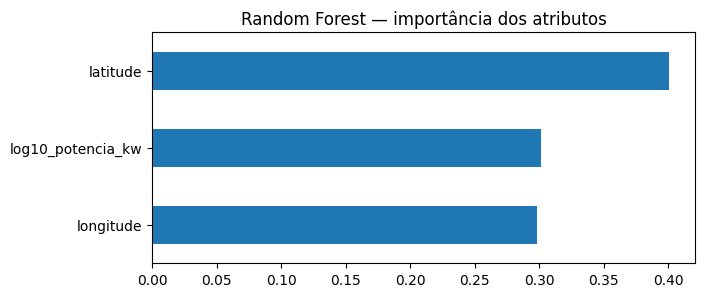

In [15]:
# Importância dos atributos no Random Forest (só para ajudar na interpretação)
pd.Series(classificadores["Random Forest"].feature_importances_, index=X.columns).sort_values().plot(
    kind="barh", title="Random Forest — importância dos atributos", figsize=(7, 3))
plt.show()

## 1.7 Checagem: esse resultado não está bom demais?

Acertar ~97% só com potência e localização me pareceu alto demais, então fui investigar **como a amostra foi montada**.

In [16]:
# 1) Onde estão os empreendimentos solares da amostra? (arredondando para 1 grau)
solar = dados_limpos[dados_limpos["fonte"] == "Solar"]
celulas = solar.groupby([solar["latitude"].round(0), solar["longitude"].round(0)]).size().sort_values(ascending=False)
print("Solares na amostra:", len(solar))
print("As 3 'células' de 1°x1° com mais solares:")
print(celulas.head(3))
print(f"=> {celulas.head(2).sum() / len(solar):.0%} dos solares estão em só 2 células do mapa")
print(f"Solares com potência <= 5 kW (microgeração): {(solar['potencia_kw'] <= 5).mean():.0%}")

# 2) Quantos pontos do teste têm 'vizinho quase idêntico' no treino?
chave = lambda df: df["latitude"].round(2).astype(str) + "_" + df["longitude"].round(2).astype(str)
repetidos = chave(X_teste).isin(set(chave(X_treino)))
print(f"\nPontos do teste com a mesma coordenada (±0,01°) já presente no treino: {repetidos.mean():.0%}")

Solares na amostra: 1200
As 3 'células' de 1°x1° com mais solares:
latitude  longitude
-2.000    -53.000      547
          -52.000      184
-6.000    -37.000       30
dtype: int64
=> 61% dos solares estão em só 2 células do mapa
Solares com potência <= 5 kW (microgeração): 64%

Pontos do teste com a mesma coordenada (±0,01°) já presente no treino: 23%


## 1.8 Interpretação — classificação

**Resultados (teste com 766 empreendimentos, divisão 80/20 estratificada, `random_state=42`, métricas com média `macro`):**

| Modelo | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Random Forest | 0,977 | 0,977 | 0,976 | 0,977 |
| KNN (k=7) | 0,967 | 0,968 | 0,966 | 0,967 |
| Regressão Logística | 0,832 | 0,847 | 0,828 | 0,825 |

**Qual modelo eu escolheria:** o **Random Forest**, que teve o maior F1 macro e errou pouco nas três classes. O KNN ficou bem perto, o que faz sentido: os dois modelos aproveitam a ideia de “empreendimentos vizinhos são do mesmo tipo”. A Regressão Logística ficou bem atrás porque ela só desenha **fronteiras retas** no espaço (potência, latitude, longitude), e a distribuição das fontes no mapa não é separável por retas (ex.: tem eólica no litoral do Nordeste e também no Rio Grande do Sul, com hidrelétricas no meio).

**Classes mais confundidas:** em todos os modelos o erro mais comum envolve a classe **Solar** (Solar → Eólica e Solar → Hidráulica). Na Regressão Logística isso é bem forte (63 solares previstas como eólicas). O motivo é que existem usinas solares grandes (dezenas de MW) no interior do Nordeste, com potência e região parecidas com parques eólicos, e solares de porte médio no Sul/Sudeste, onde predominam as hidráulicas. A confusão Hidráulica ↔ Eólica aparece no Sul, onde as duas convivem.

**Por que eu não confiaria nesses 97% numa aplicação real (limitações):**

1. **A amostra não é aleatória.** A consulta pega as primeiras 1200 linhas de cada sigla que a API devolve. Na checagem acima, a maioria dos solares está concentrada em duas pequenas regiões do mapa (perto da latitude −2°, longitude −52°/−53°) e a maior parte é microgeração de ~1 kW. Isso **não representa** a distribuição real da solar no Brasil, e deixa a tarefa artificialmente fácil.
2. **Vizinhos quase idênticos entre treino e teste.** Cerca de 23% dos pontos do teste têm a mesma coordenada (±0,01°) de algum ponto do treino (vários empreendimentos no mesmo município/condomínio, além de 28 linhas duplicadas). O KNN e o Random Forest praticamente “lembram” o vizinho. Uma avaliação mais honesta separaria treino e teste **por região** (validação espacial).
3. **Só três atributos.** Potência e localização não dizem nada sobre o recurso físico: rio e queda d'água (hidráulica), vento médio (eólica) ou irradiação (solar). Duas usinas de 30 MW no mesmo município podem ser de fontes diferentes.
4. **O cadastro mistura fases** (em operação, em construção, outorgadas) e tem erros de coordenada, como os 47 registros em (0, 0) que eu removi.
5. A contagem por classe vem do limite da consulta, então o modelo não aprendeu a proporção real das fontes no país.

# Tarefa 2 — Regressão da radiação solar (Open-Meteo)

**Pergunta:** dadas as condições do tempo e a hora em Petrolina (PE), qual é a radiação solar global horizontal (W/m²)? O alvo é **numérico** → **regressão**.

Período: 01/04/2025 a 30/06/2025, horário `America/Recife`, só horas de 7h a 17h. São dados de **modelo/reanálise**, não medição de um painel.

## 2.1 Consulta à API e geração do CSV

In [17]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39, "longitude": -40.50,
    "start_date": "2025-04-01", "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]

try:
    resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
    if "hourly" not in resposta_meteo:
        raise ValueError("Resposta sem a seção hourly")
    horas_api = resposta_meteo["hourly"]
    print("Unidades:", resposta_meteo.get("hourly_units", {}))

    linhas_regressao = []
    for indice, data_hora in enumerate(horas_api["time"]):
        hora = int(data_hora[11:13])
        valores = [horas_api[n][indice] for n in nomes_api]
        if 7 <= hora <= 17 and all(v is not None for v in valores):
            linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
    if len(linhas_regressao) < 100:
        raise ValueError("Poucos horários válidos")

    with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arq:
        escritor = csv.writer(arq)
        escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                           "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
        escritor.writerows(linhas_regressao)
    print("CSV gerado pela API:", len(linhas_regressao), "linhas")
    meteo = pd.read_csv("meteo_regressao_orange.csv", encoding="utf-8-sig")
except Exception as erro:
    print("API do Open-Meteo indisponível -> usando a cópia do repositório.", erro)
    meteo = pd.read_csv(BACKUP + "meteo_regressao_orange.csv", encoding="utf-8-sig")
    meteo.to_csv("meteo_regressao_orange.csv", index=False, encoding="utf-8-sig")

meteo.head()

API do Open-Meteo indisponível -> usando a cópia do repositório. Não foi possível consultar a API: HTTP Error 403: Forbidden


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.300,74,100,17.700,7,116.000
1,2025-04-01T08:00,26.500,66,100,18.100,8,269.000
2,2025-04-01T09:00,28.400,55,97,18.000,9,529.000
3,2025-04-01T10:00,30.800,44,21,18.400,10,797.000
4,2025-04-01T11:00,32.700,36,26,20.100,11,880.000


## 2.2 Análise exploratória

In [18]:
meteo["data_hora"] = pd.to_datetime(meteo["data_hora"])
meteo = meteo.sort_values("data_hora").reset_index(drop=True)   # garante a ordem temporal

print("Linhas x colunas:", meteo.shape)
print("Período:", meteo["data_hora"].min(), "até", meteo["data_hora"].max())
print("Dias:", meteo["data_hora"].dt.date.nunique(), "| horas por dia:", sorted(meteo["hora"].unique()))
print()
print("Valores ausentes por coluna:")
print(meteo.isna().sum())
meteo.describe()

Linhas x colunas: (1001, 7)
Período: 2025-04-01 07:00:00 até 2025-06-30 17:00:00
Dias: 91 | horas por dia: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]

Valores ausentes por coluna:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,"1,001.000","1,001.000","1,001.000","1,001.000","1,001.000","1,001.000"
mean,2025-05-16 11:59:59.999999744,28.886,50.544,55.109,15.465,12.000,472.854
min,2025-04-01 07:00:00,19.500,21.000,0.000,2.300,7.000,13.000
25%,2025-04-23 15:00:00,26.300,38.000,19.000,12.200,9.000,250.000
50%,2025-05-16 12:00:00,29.100,49.000,54.000,15.400,12.000,466.000
75%,2025-06-08 09:00:00,31.700,61.000,98.000,19.000,15.000,696.000
max,2025-06-30 17:00:00,36.100,95.000,100.000,30.100,17.000,"1,002.000"
std,NaN,3.657,15.914,37.851,4.924,3.164,256.369


In [19]:
entradas = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
print("Correlação de cada entrada com a radiação:")
meteo[entradas + ["radiacao_w_m2"]].corr()["radiacao_w_m2"].drop("radiacao_w_m2").sort_values()

Correlação de cada entrada com a radiação:


umidade_pct     -0.596
vento_kmh       -0.229
nuvens_pct      -0.180
hora             0.120
temperatura_c    0.643
Name: radiacao_w_m2, dtype: float64

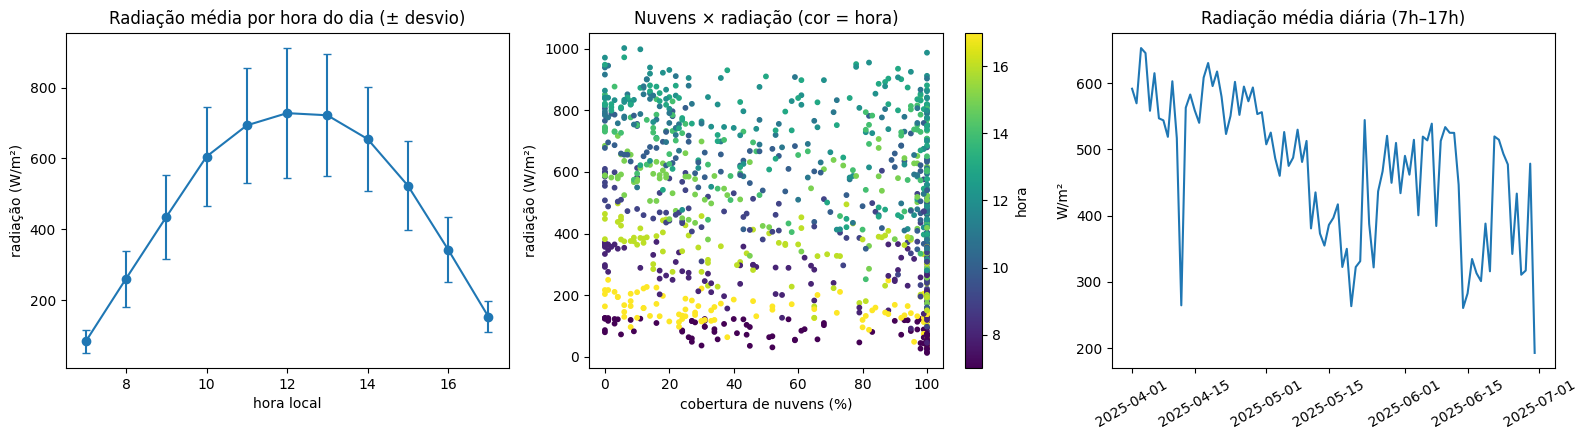

In [20]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 4.5))

media_hora = meteo.groupby("hora")["radiacao_w_m2"].agg(["mean", "std"])
eixos[0].errorbar(media_hora.index, media_hora["mean"], yerr=media_hora["std"], marker="o", capsize=3)
eixos[0].set_title("Radiação média por hora do dia (± desvio)")
eixos[0].set_xlabel("hora local"); eixos[0].set_ylabel("radiação (W/m²)")

pontos = eixos[1].scatter(meteo["nuvens_pct"], meteo["radiacao_w_m2"], c=meteo["hora"], cmap="viridis", s=10)
eixos[1].set_title("Nuvens × radiação (cor = hora)")
eixos[1].set_xlabel("cobertura de nuvens (%)"); eixos[1].set_ylabel("radiação (W/m²)")
fig.colorbar(pontos, ax=eixos[1], label="hora")

diaria = meteo.set_index("data_hora")["radiacao_w_m2"].resample("D").mean()
eixos[2].plot(diaria.index, diaria.values)
eixos[2].set_title("Radiação média diária (7h–17h)")
eixos[2].set_ylabel("W/m²"); eixos[2].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**O que eu observei:**

- Não há valores ausentes e são 11 horas (7h a 17h) por dia, nos 91 dias do período.
- A **hora** é o fator que mais manda: a radiação sobe de manhã, tem pico perto do meio-dia e cai à tarde, formando uma “curva em sino”. Por isso a correlação linear da hora com a radiação é perto de zero, mesmo ela sendo muito importante: a relação **não é linear**, é em formato de U invertido.
- As **nuvens** reduzem a radiação (correlação negativa), mas o efeito depende da hora: 100% de nuvens ao meio-dia ainda pode dar mais radiação do que céu limpo às 7h.
- Temperatura e umidade também aparecem correlacionadas, mas em parte porque elas mesmas seguem o ciclo do dia (esquenta e seca à tarde).
- Ao longo do período a radiação diária média cai um pouco (de abril para junho os dias ficam mais curtos e o sol fica mais baixo). Isso é relevante porque o teste fica justamente no final de junho.

## 2.3 Definição de X e y e divisão temporal

- `X` = as 5 entradas: `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh`, `hora`.
- `y` = `radiacao_w_m2`. **Nem ela nem nenhuma transformação dela entra em X.**
- `data_hora` serve só para ordenar e dividir.
- Divisão **temporal**: as primeiras 80% das horas são treino e as 20% finais são teste, **sem embaralhar**. Assim o modelo é avaliado em “dias futuros”, como seria no uso real.

In [21]:
X_r = meteo[entradas]
y_r = meteo["radiacao_w_m2"]

corte = int(len(meteo) * 0.8)
X_r_treino, X_r_teste = X_r.iloc[:corte], X_r.iloc[corte:]
y_r_treino, y_r_teste = y_r.iloc[:corte], y_r.iloc[corte:]

print(f"Treino: {len(X_r_treino)} horas | {meteo['data_hora'].iloc[0]} até {meteo['data_hora'].iloc[corte-1]}")
print(f"Teste : {len(X_r_teste)} horas | {meteo['data_hora'].iloc[corte]} até {meteo['data_hora'].iloc[-1]}")

Treino: 800 horas | 2025-04-01 07:00:00 até 2025-06-12 14:00:00
Teste : 201 horas | 2025-06-12 15:00:00 até 2025-06-30 17:00:00


## 2.4 Os três regressores

| Modelo | Por que escolhi |
|---|---|
| **Regressão Linear** (com `StandardScaler` no pipeline) | Baseline simples e interpretável. Esperado: dificuldade com a hora, porque a curva do dia não é uma reta. |
| **Árvore de Decisão** (`max_depth=6`) | Consegue “cortar” a hora em faixas (manhã, meio-dia, tarde) e capturar a curva. Limitei a profundidade para não decorar o treino. |
| **Random Forest** (300 árvores, `min_samples_leaf=3`) | Média de várias árvores: costuma ser mais estável e errar menos que uma árvore só. |

A padronização só faz diferença para a regressão linear (as árvores não usam escala) e, como está no pipeline, é ajustada só com o treino.

In [22]:
regressores = {
    "Regressão Linear": make_pipeline(StandardScaler(), LinearRegression()),
    "Árvore de Decisão": DecisionTreeRegressor(max_depth=6, random_state=SEMENTE),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                           random_state=SEMENTE, n_jobs=-1),
}

resultados_reg = []
previsoes_reg = {}
for nome, modelo in regressores.items():
    modelo.fit(X_r_treino, y_r_treino)
    y_prev = modelo.predict(X_r_teste)
    previsoes_reg[nome] = y_prev
    resultados_reg.append({
        "Modelo": nome,
        "MAE (W/m²)": mean_absolute_error(y_r_teste, y_prev),
        "MSE ((W/m²)²)": mean_squared_error(y_r_teste, y_prev),
        "RMSE (W/m²)": np.sqrt(mean_squared_error(y_r_teste, y_prev)),
        "R²": r2_score(y_r_teste, y_prev),
    })

tabela_reg = pd.DataFrame(resultados_reg).set_index("Modelo").sort_values("MAE (W/m²)")
print("Mesma divisão para os 3: 80% primeiras horas (treino) / 20% finais (teste), sem embaralhar")
tabela_reg

Mesma divisão para os 3: 80% primeiras horas (treino) / 20% finais (teste), sem embaralhar


,MAE (W/m²),MSE ((W/m²)²),RMSE (W/m²),R²
Modelo,,,,
Random Forest,69.277,"7,859.748",88.655,0.832
Árvore de Decisão,90.938,"15,127.027",122.992,0.678
Regressão Linear,145.205,"30,034.201",173.304,0.360


In [23]:
# Referência: um "modelo" que só usa a média por hora do treino (sem olhar o tempo)
media_por_hora = y_r_treino.groupby(X_r_treino["hora"]).mean()
y_ref = X_r_teste["hora"].map(media_por_hora)
print(f"Referência 'média por hora': MAE = {mean_absolute_error(y_r_teste, y_ref):.1f} W/m² | R² = {r2_score(y_r_teste, y_ref):.3f}")

Referência 'média por hora': MAE = 132.1 W/m² | R² = 0.287


## 2.5 Gráficos: real × previsto

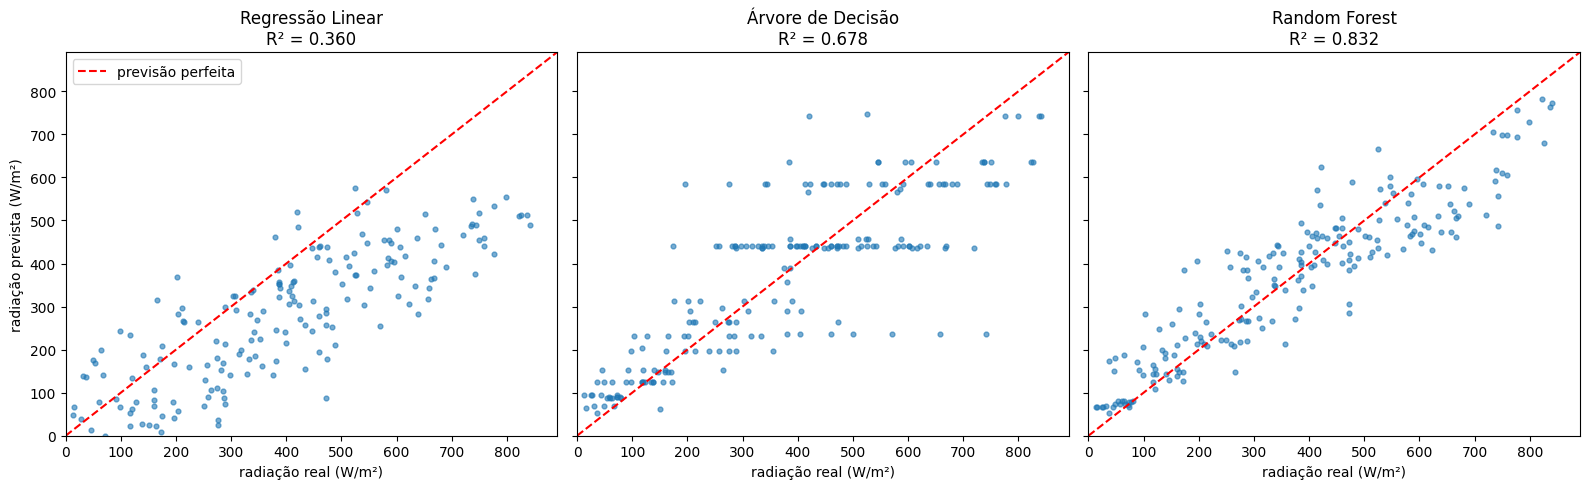

In [24]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
limite = [0, max(y_r_teste.max(), max(p.max() for p in previsoes_reg.values())) + 50]
for eixo, (nome, y_prev) in zip(eixos, previsoes_reg.items()):
    eixo.scatter(y_r_teste, y_prev, s=12, alpha=0.6)
    eixo.plot(limite, limite, "r--", label="previsão perfeita")
    eixo.set_title(f"{nome}\nR² = {r2_score(y_r_teste, y_prev):.3f}")
    eixo.set_xlabel("radiação real (W/m²)")
    eixo.set_xlim(limite); eixo.set_ylim(limite)
eixos[0].set_ylabel("radiação prevista (W/m²)")
eixos[0].legend()
plt.tight_layout(); plt.show()

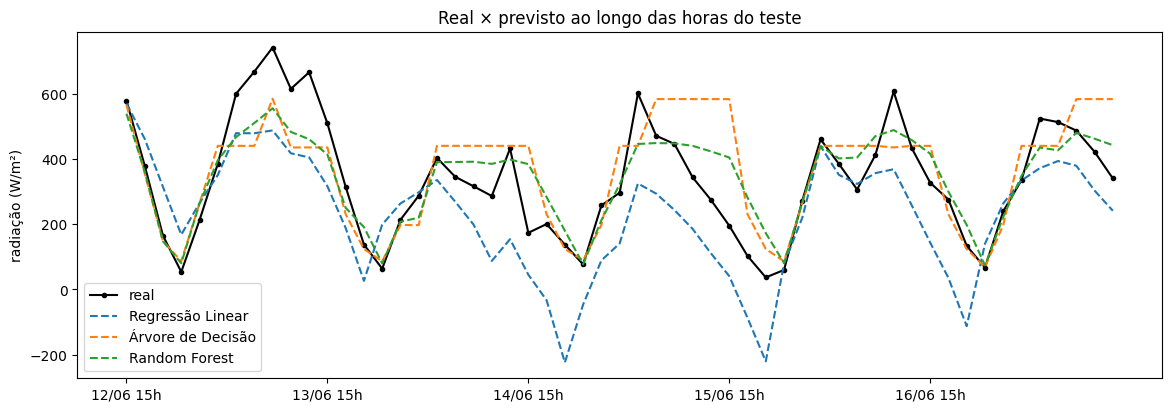

In [25]:
# Mesmo teste, ao longo do tempo (primeiros 5 dias do teste para dar para enxergar)
n = 55
datas_teste = meteo["data_hora"].iloc[corte:corte + n].dt.strftime("%d/%m %Hh")
plt.figure(figsize=(14, 4.5))
plt.plot(range(n), y_r_teste.values[:n], "k-o", ms=3, label="real")
for nome, y_prev in previsoes_reg.items():
    plt.plot(range(n), y_prev[:n], "--", label=nome)
plt.xticks(range(0, n, 11), datas_teste.iloc[::11], rotation=0)
plt.ylabel("radiação (W/m²)"); plt.title("Real × previsto ao longo das horas do teste")
plt.legend(); plt.show()

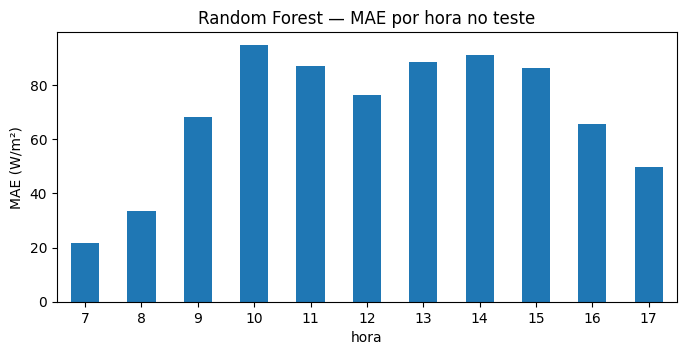

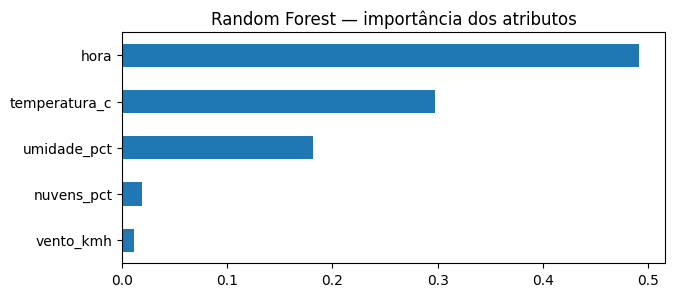

In [26]:
# Onde o melhor modelo erra mais? Erro absoluto médio por hora do dia
melhor_reg = tabela_reg.index[0]
erro_abs = np.abs(y_r_teste.values - previsoes_reg[melhor_reg])
erro_hora = pd.Series(erro_abs, index=X_r_teste["hora"].values).groupby(level=0).mean()
erro_hora.plot(kind="bar", rot=0, title=f"{melhor_reg} — MAE por hora no teste", figsize=(8, 3.5))
plt.ylabel("MAE (W/m²)"); plt.xlabel("hora"); plt.show()

imp = pd.Series(regressores["Random Forest"].feature_importances_, index=entradas).sort_values()
imp.plot(kind="barh", title="Random Forest — importância dos atributos", figsize=(7, 3)); plt.show()

## 2.6 Interpretação — regressão

**Resultados (treino = primeiras 800 horas, 01/04 a 12/06; teste = 201 horas finais, 12/06 a 30/06; sem embaralhar):**

| Modelo | MAE (W/m²) | MSE ((W/m²)²) | RMSE (W/m²) | R² |
|---|---|---|---|---|
| Random Forest | 69,3 | 7.860 | 88,7 | 0,832 |
| Árvore de Decisão | 90,9 | 15.127 | 123,0 | 0,678 |
| Regressão Linear | 145,2 | 30.034 | 173,3 | 0,360 |
| *(referência: média por hora)* | *132,1* | — | — | *0,287* |

**Qual modelo eu escolheria:** o **Random Forest**. Ele erra em média ~69 W/m² (o MAE), explica ~83% da variação da radiação no período de teste e os pontos no gráfico real × previsto ficam bem perto da diagonal. A Árvore de Decisão sozinha já melhora muito sobre a linear, mas faz previsões “em degraus” e é mais instável. A Regressão Linear é a pior: ficou só um pouco melhor que simplesmente usar a média de cada hora.

**O papel da hora do dia:** a hora é o atributo **mais importante** (quase metade da importância no Random Forest), porque define a altura do sol: a radiação média vai de ~80 W/m² às 7h para ~730 W/m² ao meio-dia e volta para ~150 W/m² às 17h. Só que essa relação tem formato de **sino**, não de reta. Por isso a correlação linear da hora com a radiação é quase zero (0,12) e a Regressão Linear não consegue usá-la direito: ela só consegue dizer “quanto mais tarde, mais (ou menos) radiação”. As árvores dividem a hora em faixas e capturam a curva. (Uma melhoria seria criar atributos como seno/cosseno da hora ou o ângulo do sol para ajudar o modelo linear.) A temperatura vem em segundo lugar, em parte porque ela também segue o ciclo do dia.

**Sobre os erros:** o maior erro absoluto acontece entre 10h e 15h, quando a radiação é maior e as nuvens fazem mais diferença (uma nuvem passando ao meio-dia derruba centenas de W/m²). Nas pontas do dia os valores são pequenos, então o erro também. Curiosamente, `nuvens_pct` teve importância baixa no Random Forest: a cobertura total de nuvens mistura nuvens altas e finas (que bloqueiam pouco) com nuvens baixas e grossas, e é um valor estimado por modelo, não observado. Outro ponto: o teste fica no fim de junho, quando a radiação média é menor (~373 W/m² contra ~498 W/m² no treino), porque é inverno e o sol fica mais baixo. Como o treino não tem nenhum dia dessa época, isso dificulta a generalização e mostra por que a divisão temporal é mais honesta que embaralhar.

**Por que estimar radiação não é o mesmo que prever geração elétrica:**

- **Unidade diferente:** radiação é uma **potência por área** (W/m²) média de uma hora. Energia gerada é **kWh**, que depende da área dos painéis, da quantidade de módulos e do tempo.
- **Plano diferente:** o alvo é radiação **horizontal**. Os painéis ficam inclinados e orientados; a radiação que chega no plano do painel é diferente (precisa de modelos de transposição).
- **Eficiência e perdas:** um módulo converte só ~20% da radiação em eletricidade, e a eficiência **cai com a temperatura** do painel. Ainda há perdas no inversor, cabos, sujeira, sombreamento, degradação e limite de potência do inversor (*clipping*).
- **Dados estimados:** os valores do Open-Meteo vêm de modelo/reanálise numa grade, não de um piranômetro nem do medidor de uma usina em Petrolina.

Ou seja, a radiação é uma **entrada** para estimar a geração, mas para chegar em kWh seria preciso um modelo da usina (ou dados reais de geração dela).

# Conclusões gerais

| Tarefa | Configuração de avaliação | Melhor modelo | Resultado |
|---|---|---|---|
| Classificação (ANEEL) | 80/20 estratificado, `random_state=42`, média `macro` | **Random Forest** | F1 macro 0,977 (KNN 0,967; Reg. Logística 0,825) |
| Regressão (Open-Meteo) | 80% primeiras horas / 20% finais, sem embaralhar | **Random Forest** | MAE 69,3 W/m², R² 0,832 (Árvore 0,678; Linear 0,360) |

O que eu aprendi com esse checkpoint:

- Nas duas tarefas os modelos baseados em árvores (e o KNN na classificação) ganharam dos modelos lineares, porque as relações **não são lineares**: a localização das fontes no mapa forma regiões irregulares, e a radiação segue uma curva em sino ao longo do dia.
- Métrica alta não significa modelo útil: na classificação, o resultado está inflado pelo jeito que a amostra foi coletada (primeiras linhas da API, pontos concentrados e quase repetidos). Antes de confiar, precisa olhar **de onde vieram os dados**.
- A forma de separar treino e teste importa: na regressão, separar pelo tempo mostrou a dificuldade real de prever semanas futuras (fim de junho, com menos sol).
- Radiação solar não é energia elétrica. Para prever geração, seria preciso juntar a radiação com dados da usina (área, inclinação, eficiência, perdas).